In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


ENCODING CATEGORICAL COLUMNS

In [4]:
le_sex = LabelEncoder()
le_smoker = LabelEncoder()
le_region = LabelEncoder()

df["sex"] = le_sex.fit_transform(df["sex"])
df["smoker"] = le_smoker.fit_transform(df["smoker"])
df["region"] = le_region.fit_transform(df["region"])

In [5]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
model = KNeighborsRegressor(n_neighbors=5)

model.fit(X_train, y_train)

print("KNN Regression Model Trained 🚀")

KNN Regression Model Trained 🚀


In [9]:
y_pred = model.predict(X_test)

In [10]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 3045.706631309701
MSE: 25690352.93092282
RMSE: 5068.565174773115
R2 Score: 0.8345213343512302


In [11]:
sample = [[
    25,   # age
    1,    # sex (encoded)
    27.5, # bmi
    0,    # children
    1,    # smoker
    2     # region
]]

sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)

print("Predicted Insurance Cost:", prediction[0])

Predicted Insurance Cost: 20758.995739999995


c:\Users\Dolly\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


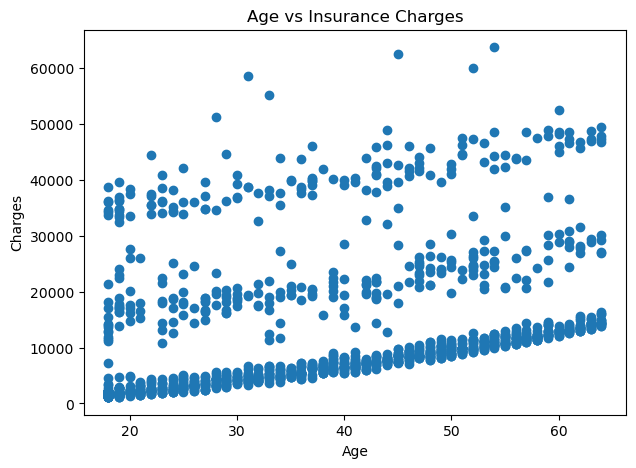

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,5))
plt.scatter(df["age"], df["charges"])
plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()